In [1]:
from IPython.core.magic import register_cell_magic


@register_cell_magic
def write_and_run(line, cell):
    argz = line.split()
    file = argz[-1]
    mode = 'w'
    if len(argz) == 2 and argz[0] == '-a':
        mode = 'a'
    with open(file, mode) as f:
        f.write(cell)
    get_ipython().run_cell(cell)


## Single Kicker Scans

[32767. 32767. 32767. ... 32767. 32767. 32767.]
Unable to Restore Initial Kicker Conditions


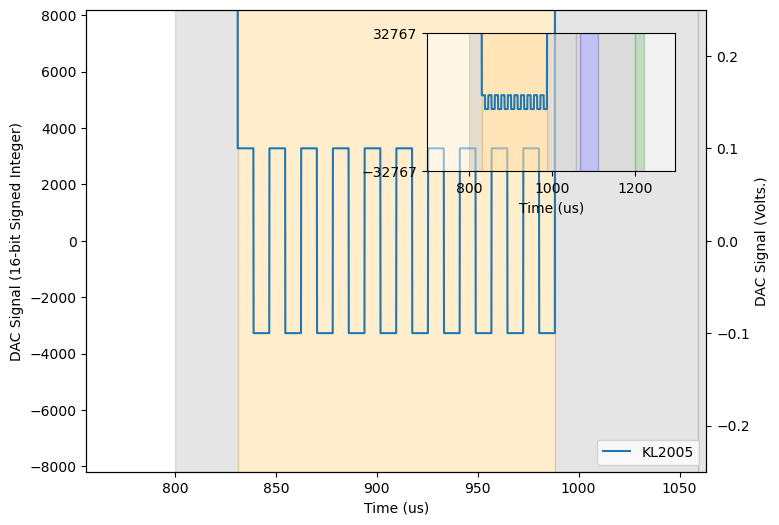

In [2]:
import numpy as np

from kickercontrol.main import SquareScan
from kickercontrol.device import (KL2005, KMX1938, KMX1965, KNY1938, KNY1965)

from kickercontrol.timing import get_region_bounds

ti, tf = get_region_bounds('2')

SquareScan(kicker_device = KL2005,
           scan_vector = np.linspace(0,10,10)/((tf-ti)),
           scan_variable="V4",
           amplitude = 0.1,
           duty = 0.5,
           n_frequency=2,
           wait_time = 1)

[32767. 32767. 32767. ... 32767. 32767. 32767.]
Unable to Restore Initial Kicker Conditions


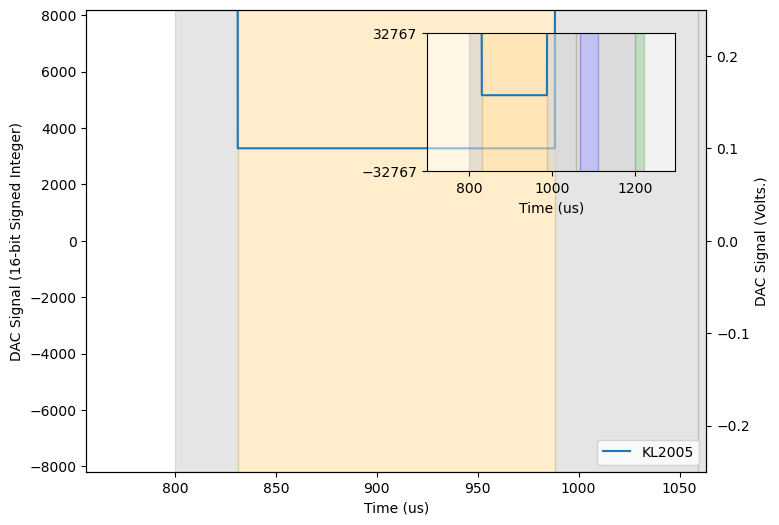

In [3]:
import numpy as np

from kickercontrol.main import MacroScan
from kickercontrol.device import (KL2005, KMX1938, KMX1965, KNY1938, KNY1965)

MacroScan(kicker_devices=[KL2005],
          scan_vectors=[np.linspace(-.1,.1,25)],
                        write_dac=True,
                        display = True,
                        beamline = '2',
                        wait_time=1)


[32767. 32767. 32767. ... 32767. 32767. 32767.]
Unable to Restore Initial Kicker Conditions


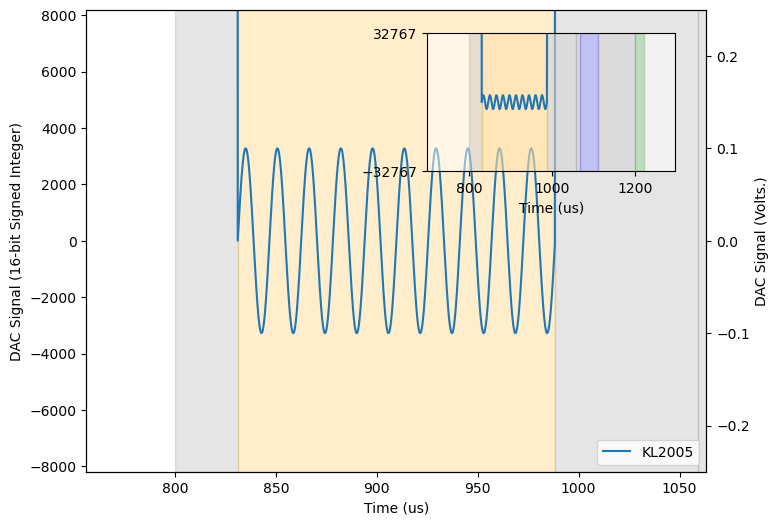

In [ ]:
import numpy as np

from kickercontrol.main import SinScan
from kickercontrol.device import (KL2005, KMX1938, KMX1965, KNY1938, KNY1965)

from kickercontrol.timing import get_region_bounds

ti, tf = get_region_bounds('2')

SinScan(kicker_device = KL2005,
           scan_vector = np.linspace(0,10,10)/((tf-ti)),
           scan_variable="V4",
           amplitude = 0.1,
           periods = 1,
           write_dac = False,
           wait_time = 1,
           display=True)

[32767. 32767. 32767. ... 32767. 32767. 32767.]
Unable to Restore Initial Kicker Conditions


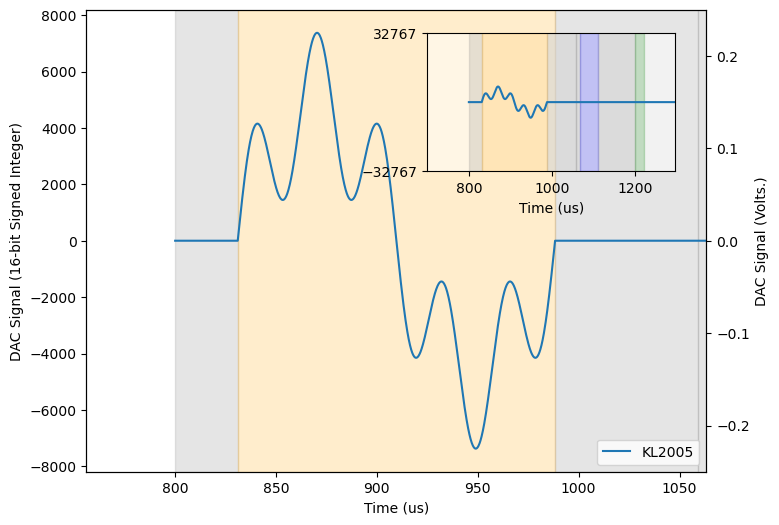

In [25]:
import numpy as np

from kickercontrol.main import Scan
from kickercontrol.device import (KL2005, KMX1938, KMX1965, KNY1938, KNY1965)

from kickercontrol.timing import get_region_bounds

ti, tf = get_region_bounds('2')

# V3: Amplitude of the first sine wave (base amplitude)
# V4: Frequency of the first sine wave (base frequency)
# V5: Fractional amplitude of the second sine wave (relative to V3)
# V6: Fractional frequency of the second sine wave (relative to V4)
# V7: Relative phase shift for the second sine wave (in radians)

Scan(kicker_devices = [KL2005],
                oscillators=['custom'],
                oscillator_variables=[{"V0": ti, "V1":tf,
                                       "V2": 0,"V3": 0.15,
                                       "V4": 1/(tf-ti),
                                       "V5":1/2, "V6": 2, "V7": 0}],
                expression = "V2 + V3 * np.sin(2 * np.pi * V4 * (t - V0)) \
      + (V5 * V3) * np.sin(2 * np.pi * (V6 * V4) * (t - V0) + V7)\
",
                  scan_variables=["V6"],
                  scan_vectors=[np.linspace(0,5,5)],
                  display = True, wait_time=1)

[32768. 32768. 32768. ... 32767. 32767. 32767.]
Unable to Restore Initial Kicker Conditions


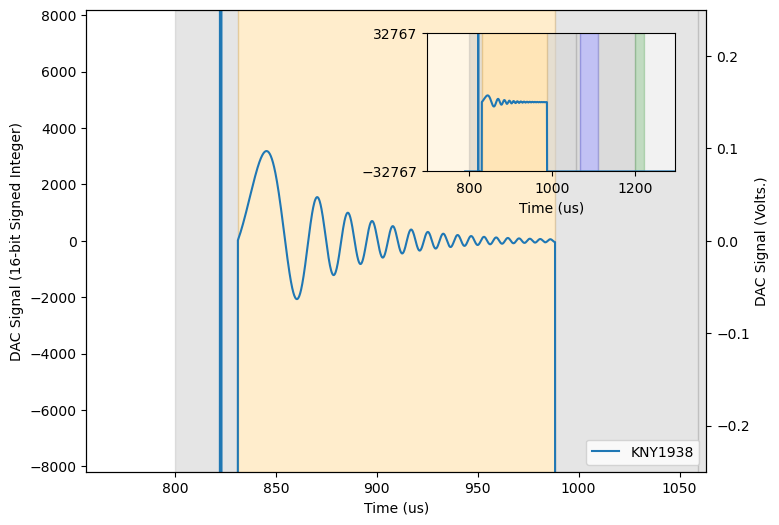

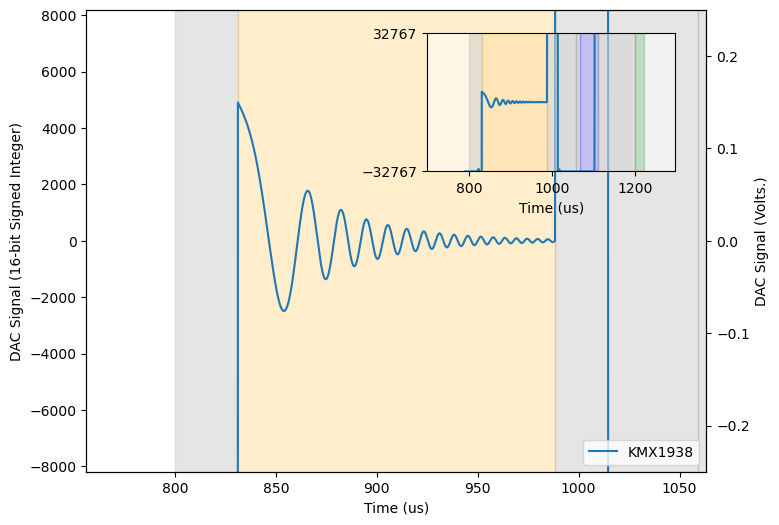

(831.0153846153846, 988.3076923076924)

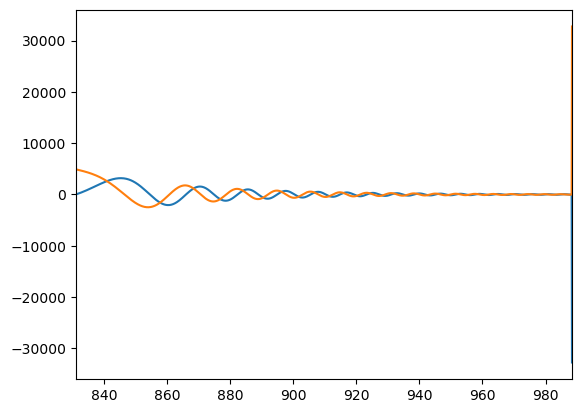

In [2]:
## Spiral

import numpy as np
from matplotlib import pyplot as plt
from kickercontrol.main import SignalGenerator
from kickercontrol.device import (KL2005, KMX1938, KMX1965, KNY1938, KNY1965)

from kickercontrol.timing import get_region_bounds

ti, tf = get_region_bounds('2')

X = SignalGenerator([KNY1938],
                oscillator_variables=[{"V0": ti,
                                       "V1": tf,
                                       "V2": 0,
                                       "V3": 0.15,
                                       "V4": 1/(tf-ti),
                                       "V5": 4.605 / (tf-ti),
                                       "V6":0.1}],
                                       oscillators=['custom'],
                                       expression="V2 + (V3 * np.exp(-V5 * (t - V0))) * np.sin(2 * np.pi * V4 * (1 + V6 * (t - V0)) * (t - V0))")


Y = SignalGenerator([KMX1938],
                oscillator_variables=[{"V0": ti,
                                       "V1": tf,
                                       "V2": 0,
                                       "V3": 0.15,
                                       "V4": 1/(tf-ti),
                                       "V5": 4.605 / (tf-ti),
                                       "V6":0.1}],
                                       oscillators=['custom'],
                                       expression="V2 + (V3 * np.exp(-V5 * (t - V0))) * np.sin(2 * np.pi * V4 * (1 + V6 * (t - V0)) * (t - V0)+np.pi/2)")
plt.show()
plt.plot(Y.dac_generators[0].generated_signal['time'],X.dac_generators[0].generated_signal)
plt.plot(Y.dac_generators[0].generated_signal['time'],Y.dac_generators[0].generated_signal)
plt.xlim(ti,tf)


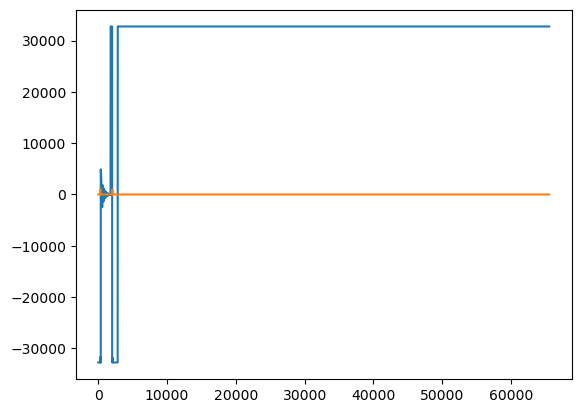

In [4]:
plt.plot(Y.dac_generators[0].generated_signal)
plt.plot(Y.dac_generators[0].kicker.read_dac()[:,1]-32767)